In [1]:
import pandas as pd

df = pd.read_csv("Airbnb_Open_Data.csv")
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

/tmp/ipykernel_298/1499595385.py:3: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Airbnb_Open_Data.csv")


In [2]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [3]:
print(df.describe())

                 id       host id            lat           long  \
count  1.025990e+05  1.025990e+05  102591.000000  102591.000000   
mean   2.914623e+07  4.925411e+10      40.728094     -73.949644   
std    1.625751e+07  2.853900e+10       0.055857       0.049521   
min    1.001254e+06  1.236005e+08      40.499790     -74.249840   
25%    1.508581e+07  2.458333e+10      40.688740     -73.982580   
50%    2.913660e+07  4.911774e+10      40.722290     -73.954440   
75%    4.320120e+07  7.399650e+10      40.762760     -73.932350   
max    5.736742e+07  9.876313e+10      40.916970     -73.705220   

       Construction year  minimum nights  number of reviews  \
count      102385.000000   102190.000000      102416.000000   
mean         2012.487464        8.135845          27.483743   
std             5.765556       30.553781          49.508954   
min          2003.000000    -1223.000000           0.000000   
25%          2007.000000        2.000000           1.000000   
50%          2012.

In [4]:
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]', '', regex=True).astype(float)

In [5]:
df['reviews per month'] = pd.to_numeric(
    df['reviews per month'],
    errors='coerce'
)

df['reviews per month'] = df['reviews per month'].fillna(0)

df['review rate number'] = df['review rate number'].fillna(
    df['review rate number'].median()
)

df['minimum nights'] = df['minimum nights'].fillna(
    df['minimum nights'].median()
)

In [6]:
df.drop(['id', 'host id', 'license', 'house_rules'], axis=1, inplace=True)

In [7]:
df['host_identity_verified'] = df['host_identity_verified'].map({'t':1, 'f':0})

In [8]:
df = df[df['minimum nights'] >= 0]

df = df[(df['availability 365'] >= 0) & (df['availability 365'] <= 365)]

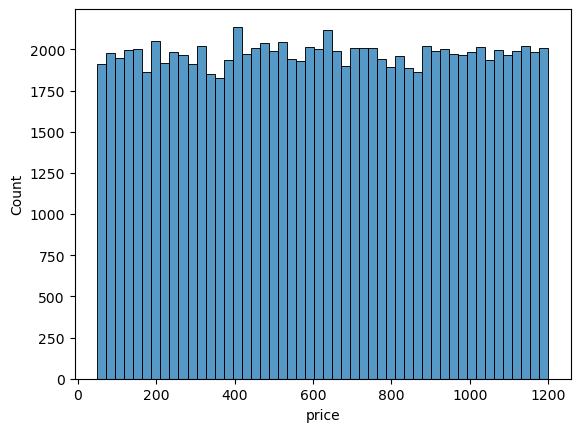

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['price'], bins=50)
plt.show()

In [10]:
top_price = df.groupby('neighbourhood group')['price'].mean().sort_values(ascending=False)
print(top_price)

neighbourhood group
Queens           629.577313
Bronx            628.157299
Brooklyn         626.744569
Staten Island    624.998926
Manhattan        623.430683
brookln          580.000000
manhatan         460.000000
Name: price, dtype: float64


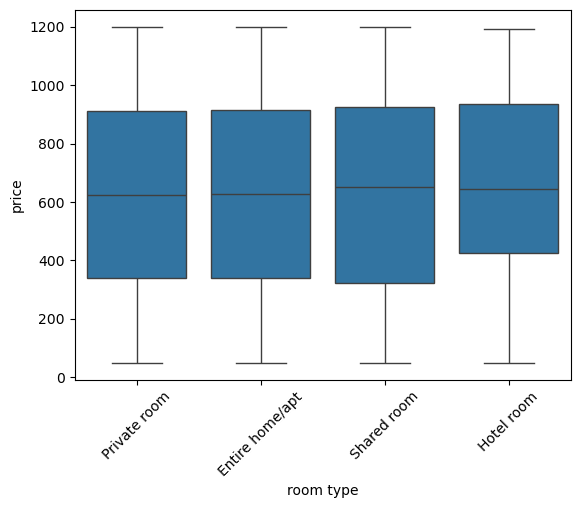

In [11]:
sns.boxplot(x='room type', y='price', data=df)
plt.xticks(rotation=45)
plt.show()

In [12]:
df = pd.get_dummies(df, columns=['room type','neighbourhood group'], drop_first=True)

In [13]:
from sklearn.model_selection import train_test_split

X = df.select_dtypes(include=['float64','int64'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
print(df.head())

                                               NAME  host_identity_verified  \
0                Clean & quiet apt home by the park                     NaN   
1                             Skylit Midtown Castle                     NaN   
2               THE VILLAGE OF HARLEM....NEW YORK !                     NaN   
3                                               NaN                     NaN   
4  Entire Apt: Spacious Studio/Loft by central park                     NaN   

  host name neighbourhood       lat      long        country country code  \
0  Madaline    Kensington  40.64749 -73.97237  United States           US   
1     Jenna       Midtown  40.75362 -73.98377  United States           US   
2     Elise        Harlem  40.80902 -73.94190  United States           US   
3     Garry  Clinton Hill  40.68514 -73.95976  United States           US   
4    Lyndon   East Harlem  40.79851 -73.94399  United States           US   

  instant_bookable cancellation_policy  ...  availability 365 

In [15]:
df['host_identity_verified'].value_counts(dropna=False)

host_identity_verified
NaN    98925
Name: count, dtype: int64

In [16]:
len(df)

98925

In [17]:
df = df.drop(columns=['host_identity_verified'])

In [18]:
df.isna().sum().sort_values(ascending=False)


last review                          15024
country                                512
host name                              388
calculated host listings count         290
service fee                            262
price                                  235
NAME                                   223
Construction year                      173
number of reviews                      128
country code                           107
instant_bookable                        81
cancellation_policy                     56
neighbourhood                           13
lat                                      8
long                                     8
minimum nights                           0
reviews per month                        0
review rate number                       0
availability 365                         0
room type_Hotel room                     0
room type_Private room                   0
room type_Shared room                    0
neighbourhood group_Brooklyn             0
neighbourho

In [19]:
(df.isna().mean() * 100).sort_values(ascending=False)

last review                          15.187263
country                               0.517564
host name                             0.392216
calculated host listings count        0.293151
service fee                           0.264847
price                                 0.237554
NAME                                  0.225423
Construction year                     0.174880
number of reviews                     0.129391
country code                          0.108163
instant_bookable                      0.081880
cancellation_policy                   0.056609
neighbourhood                         0.013141
lat                                   0.008087
long                                  0.008087
minimum nights                        0.000000
reviews per month                     0.000000
review rate number                    0.000000
availability 365                      0.000000
room type_Hotel room                  0.000000
room type_Private room                0.000000
room type_Sha

In [20]:
df['country'] = df['country'].fillna(df['country'].mode()[0])

In [21]:
df = df.drop(columns=['host name'])

In [22]:
df['calculated host listings count'] = df['calculated host listings count'].fillna(
    df['calculated host listings count'].median()
)

In [23]:
df['price'].dtype
df['service fee'].dtype

dtype('float64')

In [24]:
df['price'] = df['price'].fillna(df['price'].median())

In [25]:
df.columns

Index(['NAME', 'neighbourhood', 'lat', 'long', 'country', 'country code',
       'instant_bookable', 'cancellation_policy', 'Construction year', 'price',
       'service fee', 'minimum nights', 'number of reviews', 'last review',
       'reviews per month', 'review rate number',
       'calculated host listings count', 'availability 365',
       'room type_Hotel room', 'room type_Private room',
       'room type_Shared room', 'neighbourhood group_Brooklyn',
       'neighbourhood group_Manhattan', 'neighbourhood group_Queens',
       'neighbourhood group_Staten Island', 'neighbourhood group_brookln',
       'neighbourhood group_manhatan'],
      dtype='object')

In [26]:
df['Construction year'] = df['Construction year'].fillna(
    df['Construction year'].median()
)

In [27]:
df = df.dropna(subset=['lat','long'])

In [28]:
df['neighbourhood group_Manhattan'] = (
    df['neighbourhood group_Manhattan'] |
    df['neighbourhood group_manhatan']
).astype(int)

df = df.drop(columns=['neighbourhood group_manhatan'])

In [29]:
df['neighbourhood group_Brooklyn'] = (
    df['neighbourhood group_Brooklyn'] |
    df['neighbourhood group_brookln']
).astype(int)

df = df.drop(columns=['neighbourhood group_brookln'])

In [30]:
df.isna().sum().sort_values(ascending=False)

last review                          15023
service fee                            262
NAME                                   223
number of reviews                      128
country code                           107
instant_bookable                        81
cancellation_policy                     56
neighbourhood                           13
country                                  0
Construction year                        0
lat                                      0
long                                     0
price                                    0
minimum nights                           0
reviews per month                        0
review rate number                       0
calculated host listings count           0
availability 365                         0
room type_Hotel room                     0
room type_Private room                   0
room type_Shared room                    0
neighbourhood group_Brooklyn             0
neighbourhood group_Manhattan            0
neighbourho

In [31]:
df = df.drop(columns=['NAME'])

In [32]:
df = df.drop(columns=['last review'])

In [33]:
df['service fee'] = df['service fee'].fillna(
    df['service fee'].median()
)

In [34]:
df['number of reviews'] = df['number of reviews'].fillna(
    df['number of reviews'].median()
)

In [35]:
df['country code'].unique()

array(['US', nan], dtype=object)

In [36]:
df = df.drop(columns=['country code'])

In [37]:
df['cancellation_policy'] = df['cancellation_policy'].fillna(
    df['cancellation_policy'].mode()[0]
)

In [38]:
df['neighbourhood'] = df['neighbourhood'].fillna(
    df['neighbourhood'].mode()[0]
)

In [39]:
df.isna().sum()

neighbourhood                         0
lat                                   0
long                                  0
country                               0
instant_bookable                     81
cancellation_policy                   0
Construction year                     0
price                                 0
service fee                           0
minimum nights                        0
number of reviews                     0
reviews per month                     0
review rate number                    0
calculated host listings count        0
availability 365                      0
room type_Hotel room                  0
room type_Private room                0
room type_Shared room                 0
neighbourhood group_Brooklyn          0
neighbourhood group_Manhattan         0
neighbourhood group_Queens            0
neighbourhood group_Staten Island     0
dtype: int64

In [40]:
df['instant_bookable'] = df['instant_bookable'].fillna(
    df['instant_bookable'].mode()[0]
)

/tmp/ipykernel_298/2210312946.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['instant_bookable'] = df['instant_bookable'].fillna(


In [41]:
df['instant_bookable'].unique()

array([False,  True])

In [42]:
df['instant_bookable'] = (
    df['instant_bookable']
        .fillna(df['instant_bookable'].mode()[0])
        .astype(str)
        .str.lower()
        .map({'true': 1, 'false': 0, 'yes': 1, 'no': 0})
)

In [43]:
df['price'].describe()

count    98917.000000
mean       625.754703
std        331.341371
min         50.000000
25%        341.000000
50%        626.000000
75%        913.000000
max       1200.000000
Name: price, dtype: float64

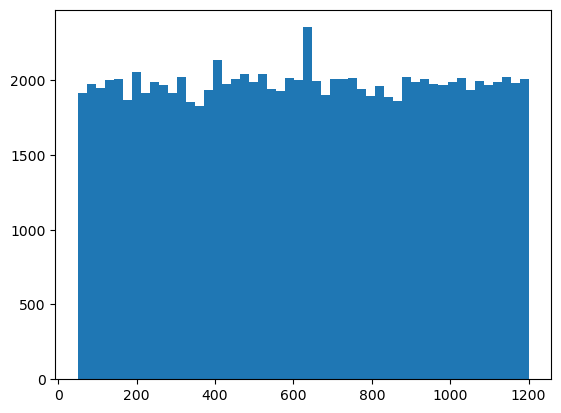

In [44]:
import matplotlib.pyplot as plt

plt.hist(df['price'], bins=50)
plt.show()

In [45]:
df.corr(numeric_only=True)['price'].sort_values(ascending=False)

price                                1.000000
service fee                          0.997842
number of reviews                    0.006117
reviews per month                    0.005486
neighbourhood group_Queens           0.004503
room type_Hotel room                 0.004417
room type_Shared room                0.003192
neighbourhood group_Brooklyn         0.002456
long                                 0.001446
instant_bookable                     0.000461
calculated host listings count      -0.000212
neighbourhood group_Staten Island   -0.000222
availability 365                    -0.001725
room type_Private room              -0.002188
Construction year                   -0.004539
minimum nights                      -0.004775
neighbourhood group_Manhattan       -0.005989
lat                                 -0.005990
review rate number                  -0.006181
Name: price, dtype: float64

<Axes: xlabel='room type_Hotel room', ylabel='price'>

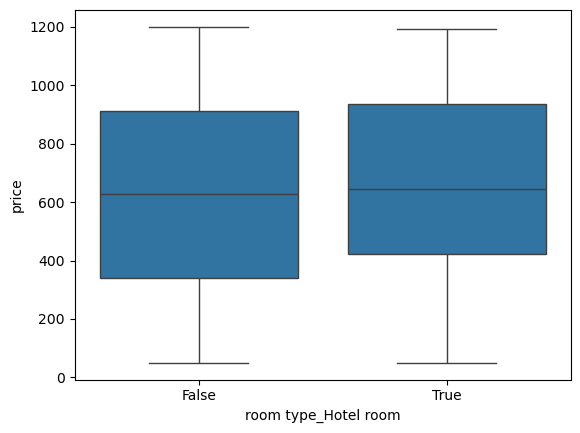

In [46]:
import seaborn as sns
sns.boxplot(x='room type_Hotel room', y='price', data=df)

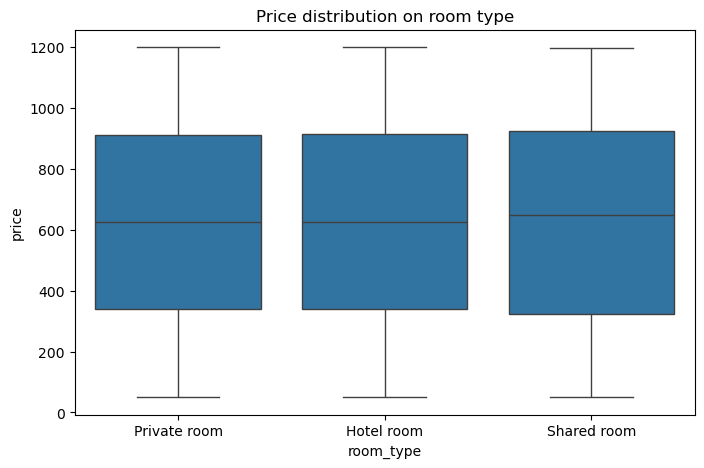

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

room_cols = ['room type_Hotel room', 'room type_Private room', 'room type_Shared room']

df['room_type'] = df[room_cols].idxmax(axis=1).str.replace('room type_', '')

plt.figure(figsize=(8,5))
sns.boxplot(x='room_type', y='price', data=df)
plt.title("Price distribution on room type")
plt.show()

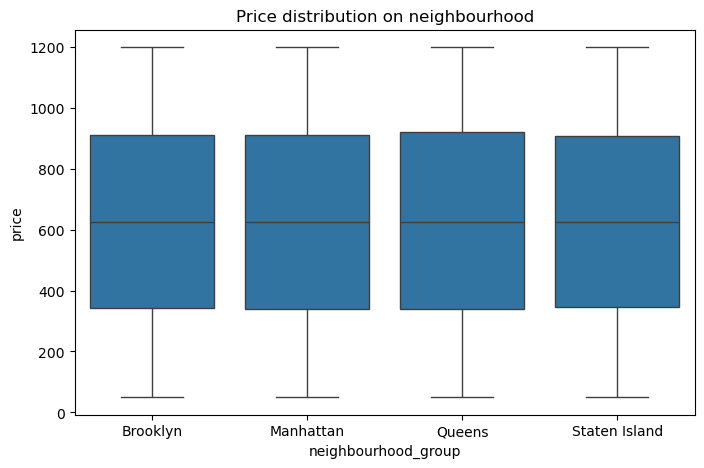

In [48]:
nb_cols = ['neighbourhood group_Brooklyn', 'neighbourhood group_Manhattan', 
           'neighbourhood group_Queens', 'neighbourhood group_Staten Island']

df['neighbourhood_group'] = df[nb_cols].idxmax(axis=1).str.replace('neighbourhood group_', '')

plt.figure(figsize=(8,5))
sns.boxplot(x='neighbourhood_group', y='price', data=df)
plt.title("Price distribution on neighbourhood")
plt.show()

In [49]:
# NU folosim service fee, pentru că e aproape identic cu prețul
df = df.drop(columns=['service fee'])

In [54]:
print(f"X shape: {X.shape[0]}")
print(f"y shape: {y.shape[0]}")

X shape: 98925
y shape: 98917


In [56]:
print(df.columns.tolist())

['neighbourhood', 'lat', 'long', 'country', 'instant_bookable', 'cancellation_policy', 'Construction year', 'price', 'minimum nights', 'number of reviews', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'room type_Hotel room', 'room type_Private room', 'room type_Shared room', 'neighbourhood group_Brooklyn', 'neighbourhood group_Manhattan', 'neighbourhood group_Queens', 'neighbourhood group_Staten Island', 'room_type', 'neighbourhood_group']


In [57]:
# 1. Create the 'has_review' column (it's likely a boolean)
df['has_review'] = df['number of reviews'] > 0

# 2. Define your features (now 'has_review' exists!)
feature_cols = [
    'minimum nights', 'number of reviews', 'reviews per month', 
    'review rate number', 'calculated host listings count', 
    'availability 365', 'has_review', 'room type_Hotel room', 
    'room type_Private room', 'room type_Shared room', 
    'neighbourhood group_Brooklyn', 'neighbourhood group_Manhattan', 
    'neighbourhood group_Queens', 'neighbourhood group_Staten Island'
]

# 3. Drop rows where 'price' is missing to fix the row mismatch (98925 vs 98917)
df_filtered = df.dropna(subset=['price'])

# 4. Final Assignment
X = df_filtered[feature_cols]
y = df_filtered['price']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (98917, 14)
y shape: (98917,)


In [58]:
# 1. Drop rows where 'price' is NaN from the main dataframe
df_filtered = df.dropna(subset=['price'])

# 2. Re-assign X and y using the filtered dataframe
X = df_filtered[feature_cols]
y = df_filtered['price']

# 3. Verify they match now
print(f"X shape: {X.shape[0]}")
print(f"y shape: {y.shape[0]}")

# 4. Now the split will work
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X shape: 98917
y shape: 98917


In [59]:
print(X.isnull().sum())

minimum nights                       0
number of reviews                    0
reviews per month                    0
review rate number                   0
calculated host listings count       0
availability 365                     0
has_review                           0
room type_Hotel room                 0
room type_Private room               0
room type_Shared room                0
neighbourhood group_Brooklyn         0
neighbourhood group_Manhattan        0
neighbourhood group_Queens           0
neighbourhood group_Staten Island    0
dtype: int64


In [60]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R2:", r2)

MSE: 109770.22079981193
R2: -0.0003845010640217694


In [61]:
import pandas as pd

coefs = pd.Series(model.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(coefs)

room type_Hotel room                 41.787049
neighbourhood group_Staten Island    -9.346756
neighbourhood group_Queens            5.298279
has_review                            4.788543
room type_Private room               -4.643367
room type_Shared room                -4.272202
neighbourhood group_Manhattan        -1.957692
review rate number                   -1.817230
neighbourhood group_Brooklyn          1.424168
reviews per month                     0.188627
minimum nights                       -0.060512
number of reviews                     0.031553
calculated host listings count        0.015008
availability 365                     -0.003697
dtype: float64


In [62]:
from sklearn.model_selection import train_test_split

# Această celulă TREBUIE rulată înainte de antrenarea modelului
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Inițializăm și antrenăm modelul
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train) # Acum X_train va fi recunoscut

# Realizăm predicțiile
y_pred_rf = rf_model.predict(X_test)

# Evaluăm
print(f"Random Forest MSE: {mean_squared_error(y_test, y_pred_rf)}")
print(f"Random Forest R2 Score: {r2_score(y_test, y_pred_rf)}")

Random Forest MSE: 76141.1973526892
Random Forest R2 Score: 0.3060916415299978


/tmp/ipykernel_298/1655286966.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


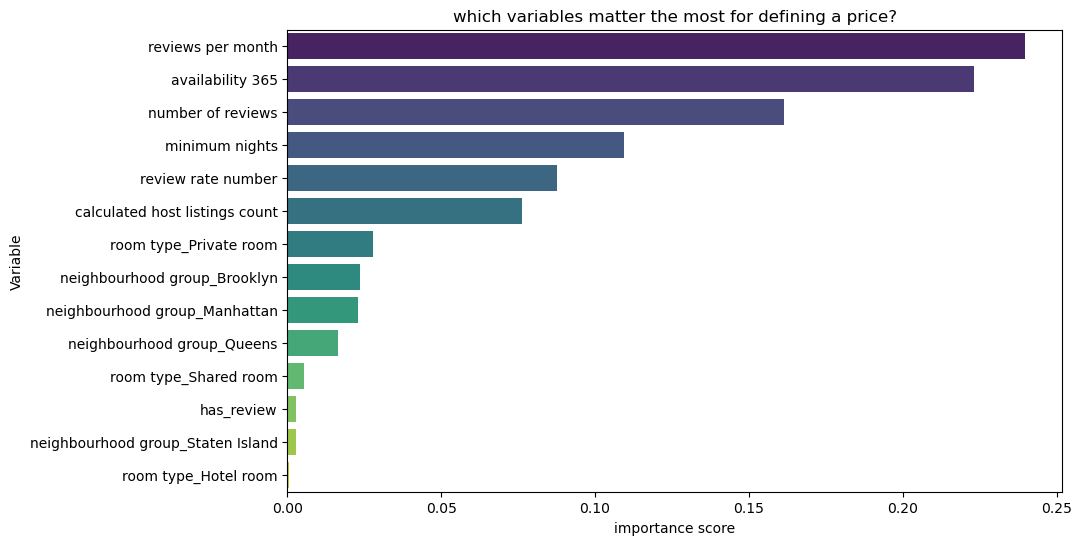

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extragem importanța fiecărei trăsături
importances = rf_model.feature_importances_
feature_names = X.columns

# 2. Creăm un DataFrame pentru vizualizare
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# 3. Desenăm graficul
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('which variables matter the most for defining a price?')
plt.xlabel('importance score')
plt.ylabel('Variable')
plt.show()

In [66]:
# Selectăm doar variabilele care au arătat o importanță semnificativă
top_features = [
    'reviews per month', 'availability 365', 'number of reviews', 
    'minimum nights', 'review rate number', 'calculated host listings count',
    'room type_Private room', 'neighbourhood group_Brooklyn', 
    'neighbourhood group_Manhattan'
]

X_top = df[top_features]

X_train_top, X_test_top, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, random_state=42
)

In [69]:

X_train_sample = X_train_top.sample(20000, random_state=42)
y_train_sample = y_train.loc[X_train_sample.index]

# 2. Setăm căutarea să fie și mai scurtă
rf_random_fast = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=5, # Căutăm doar 5 rețete în loc de 10
    cv=2,     # Verificăm de 2 ori în loc de 3
    verbose=2,
    random_state=42,
    n_jobs=-1 
)

print("start")
rf_random_fast.fit(X_train_sample, y_train_sample)
print("done!")

# Vedem rezultatul
best_model = rf_random_fast.best_estimator_
y_pred_best = best_model.predict(X_test_top)
print(f"R2 score : {r2_score(y_test, y_pred_best)}")

start
Fitting 2 folds for each of 5 candidates, totalling 10 fits
done!
R2 score : 0.0461339577284825


In [70]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Transformăm prețul în 3 categorii (Low, Medium, High)
# Folosim qcut pentru a ne asigura că avem un număr egal de apartamente în fiecare grupă
df['price_category'] = pd.qcut(df['price'], q=3, labels=['Low', 'Medium', 'High'])

# 2. Pregătim noile date pentru antrenare
y_class = df['price_category']
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)

# 3. Antrenăm Clasificatorul
clf_model = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42)
clf_model.fit(X_train_c, y_train_c)

# 4. Facem predicții
y_pred_c = clf_model.predict(X_test_c)

# 5. Afișăm performanța
print(f"Precizia Modelului (Accuracy): {accuracy_score(y_test_c, y_pred_c):.2f}")
print("\nRaport detaliat:")
print(classification_report(y_test_c, y_pred_c))

Precizia Modelului (Accuracy): 0.53

Raport detaliat:
              precision    recall  f1-score   support

        High       0.52      0.52      0.52      6600
         Low       0.53      0.52      0.52      6628
      Medium       0.52      0.55      0.53      6556

    accuracy                           0.53     19784
   macro avg       0.53      0.53      0.53     19784
weighted avg       0.53      0.53      0.53     19784



/tmp/ipykernel_298/2188358325.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df_clf, palette='magma')


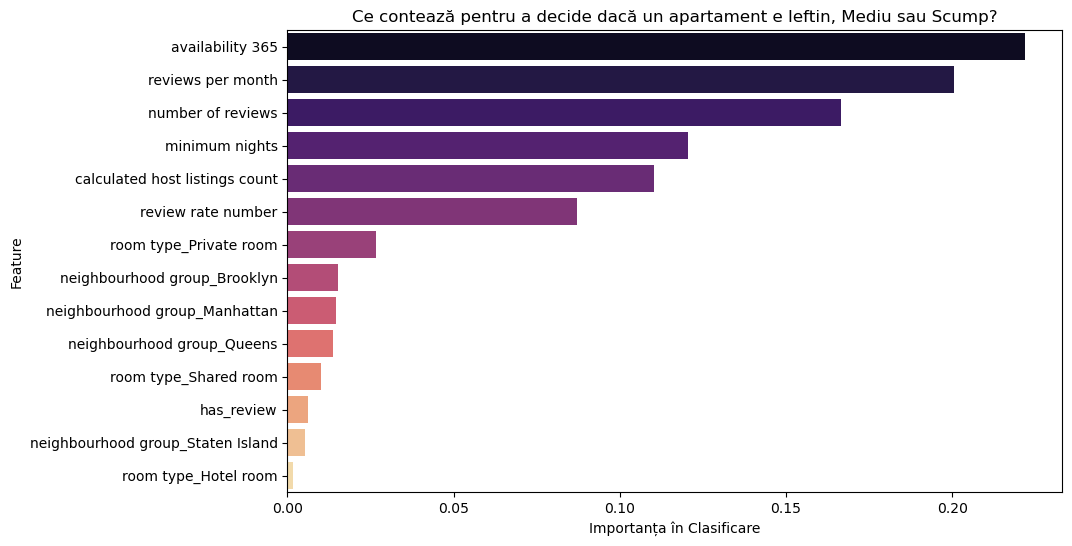

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extragem importanța din noul model de clasificare
importances_clf = clf_model.feature_importances_
feature_names = feature_cols

# 2. Creăm DataFrame-ul pentru vizualizare
importance_df_clf = pd.DataFrame({'Feature': feature_names, 'Importance': importances_clf})
importance_df_clf = importance_df_clf.sort_values(by='Importance', ascending=False)

# 3. Desenăm graficul
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df_clf, palette='magma')
plt.title('Ce contează pentru a decide dacă un apartament e Ieftin, Mediu sau Scump?')
plt.xlabel('Importanța în Clasificare')
plt.show()